# SFT Training Notebook (from run_sft.py)

此 notebook 将 `run_sft.py` 的主要逻辑转换为可交互的 cells，并做了设备检测与 CUDA 优化提示，便于在本地 RTX 4060 上运行。按顺序运行所有 code cells 即可。

In [1]:
# 环境与依赖 imports
import os
os.environ['TIKTOKEN_CACHE_DIR'] = os.path.expanduser('~/.cache/tiktoken')
import json
import gc
from functools import partial

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken

# 推荐：在 RTX 4060 上启用 cudnn benchmark 来优化小批量行为（如输入长度一致时有效）
torch.backends.cudnn.benchmark = True

# 导入本目录下的 GPTModel 和工具函数（确保 utils.py 在同一目录或已安装）
from utils import GPTModel, plot_losses

# 设备选择：优先使用 cuda:0（如果可用），并打印 GPU 信息以确认是 RTX 4060
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    try:
        torch.cuda.set_device(0)
    except Exception:
        pass

print('Using device:', device)
if device.type == 'cuda':
    try:
        print('GPU:', torch.cuda.get_device_name(0))
        total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'Total memory: {total_mem:.2f} GB')
    except Exception as e:
        print('Could not query GPU info:', e)

Using device: cuda:0
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Total memory: 8.59 GB


In [2]:
# 文本格式化与 Dataset/Collate 实现
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry.get('input')}" if entry.get('input') else ""
    return instruction_text + input_text

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry.get('output','')}"
            full_text = instruction_plus_input + response_text + '<|endoftext|>'
            encoded = tokenizer.encode(full_text, allowed_special={'<|endoftext|>'})
            self.encoded_texts.append(encoded)

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

class InstructionDatasetMask(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.instruction_lengths = []
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry.get('output','')}"
            full_text = instruction_plus_input + response_text + '<|endoftext|>'
            encoded = tokenizer.encode(full_text, allowed_special={'<|endoftext|>'})
            self.encoded_texts.append(encoded)
            instruction_encoded = tokenizer.encode(instruction_plus_input, allowed_special={'<|endoftext|>'})
            self.instruction_lengths.append(len(instruction_encoded))

    def __getitem__(self, index):
        return self.instruction_lengths[index], self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device='cpu'):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_list, targets_list = [], []
    for item in batch:
        padded = item + [pad_token_id] * (batch_max_length - len(item))
        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)
        mask_indices = (targets == pad_token_id)
        first_pad_idx = mask_indices.nonzero(as_tuple=True)[0]
        if len(first_pad_idx) > 0:
            mask_indices[first_pad_idx[0]] = False
        targets[mask_indices] = ignore_index
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_list.append(inputs)
        targets_list.append(targets)
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)
    return inputs_tensor, targets_tensor

def custom_collate_fn_mask(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device='cpu'):
    batch_max_length = max(len(item[1]) + 1 for item in batch)
    inputs_list, targets_list = [], []
    for instruction_length, item in batch:
        padded = item + [pad_token_id] * (batch_max_length - len(item))
        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)
        mask_indices = (targets == pad_token_id)
        first_pad_idx = mask_indices.nonzero(as_tuple=True)[0]
        if len(first_pad_idx) > 0:
            mask_indices[first_pad_idx[0]] = False
        targets[mask_indices] = ignore_index
        if instruction_length > 1:
            targets[:instruction_length-1] = ignore_index
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_list.append(inputs)
        targets_list.append(targets)
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)
    return inputs_tensor, targets_tensor

In [3]:
def init_data_loaders(data, tokenizer, batch_size, dataset_class, collate_fn):
    train_portion = int(len(data) * 0.85)
    test_portion = int(len(data) * 0.1)
    val_portion = len(data) - train_portion - test_portion
    train_data = data[:train_portion]
    test_data = data[train_portion:train_portion + test_portion]
    val_data = data[train_portion + test_portion:]
    train_dataset = dataset_class(train_data, tokenizer)
    test_dataset = dataset_class(test_data, tokenizer)
    val_dataset = dataset_class(val_data, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return train_loader, test_loader, val_loader

In [4]:
def train_model(model, optimizer, device, n_epochs, train_loader, val_loader, use_amp=False, grad_accum_steps=1, max_grad_norm=None, log_interval=50, early_stop_patience=2, min_delta=1e-4):
    """训练主循环，打印更详细的 progress（epoch, step, train loss, val loss）。"""
    train_losses, val_losses = [], []
    amp_enabled = use_amp and device.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0
        optimizer.zero_grad(set_to_none=True)
        for step, (inputs, targets) in enumerate(train_loader, 1):
            inputs, targets = inputs.to(device), targets.to(device)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                logits = model(inputs)
                loss = loss_fn(logits.view(-1, logits.size(-1)), targets.view(-1))
            raw_loss = loss.item()
            loss = loss / max(1, grad_accum_steps)
            scaler.scale(loss).backward()
            if step % grad_accum_steps == 0 or step == len(train_loader):
                if max_grad_norm is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running_loss += raw_loss
            n_batches += 1
            # 实时打印 step 级别的进度（包括 epoch, step, 当前 batch loss, 平均 train loss）
            if step % log_interval == 0 or step == len(train_loader):
                avg_so_far = running_loss / n_batches if n_batches>0 else float('nan')
                print(f'[Train][Epoch {epoch+1}/{n_epochs}] Step {step}/{len(train_loader)} | batch_loss={raw_loss:.4f} | avg_train_loss_so_far={avg_so_far:.4f}')
        avg_train = running_loss / n_batches if n_batches>0 else None
        train_losses.append(avg_train)
        # 验证阶段
        model.eval()
        val_loss_total = 0.0
        val_steps = 0
        with torch.no_grad():
            for v_inputs, v_targets in val_loader:
                v_inputs, v_targets = v_inputs.to(device), v_targets.to(device)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    v_logits = model(v_inputs)
                    v_loss = loss_fn(v_logits.view(-1, v_logits.size(-1)), v_targets.view(-1))
                val_loss_total += v_loss.item()
                val_steps += 1
        avg_val = val_loss_total / val_steps if val_steps>0 else None
        val_losses.append(avg_val)
        print(f'[Epoch {epoch+1}/{n_epochs}] train_loss={avg_train:.4f} | val_loss={avg_val:.4f}')
        # 早停与保存最佳模型
        if avg_val is not None and avg_val < best_val - min_delta:
            best_val = avg_val
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
            print(f'  -> New best val_loss={best_val:.4f}')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    return train_losses, val_losses, best_state

In [5]:
def generate(model, input_ids, max_new_tokens=100, stop_token_id=None):
    model.eval()
    idx = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(idx)
            logits = logits[:, -1, :]
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat([idx, next_token], dim=1)
            if stop_token_id is not None and next_token.item() == stop_token_id:
                break
    return idx

def clean_model_response(text):
    text = text.strip()
    if '### Response:' in text:
        text = text.split('### Response:', 1)[-1].strip()
    if '### Instruction:' in text:
        text = text.split('### Instruction:', 1)[0].strip()
    return text

In [6]:
def main(args):
    """执行一次训练/验证/保存/生成流程，返回字典包含损失和路径。"""
    tokenizer = tiktoken.get_encoding('gpt2')
    pad_token = tokenizer.eot_token
    if args.mask_instructions == 1:
        CustomDataset = InstructionDatasetMask
        collate_fn = partial(custom_collate_fn_mask, allowed_max_length=args.allowed_max_length, device=device)
    else:
        CustomDataset = InstructionDataset
        collate_fn = partial(custom_collate_fn, allowed_max_length=args.allowed_max_length, device=device)
    with open(args.data, 'r', encoding='utf-8') as f:
        data = json.load(f)
    train_loader, test_loader, val_loader = init_data_loaders(data, tokenizer, args.batch_size, CustomDataset, collate_fn)
    print(f"Data loaded. total={len(data)}, train_batches={len(train_loader)}, val_batches={len(val_loader)}, test_batches={len(test_loader)}")
    BASE_CONFIG = {'vocab_size':50257, 'context_length':1024, 'drop_rate':0.0, 'qkv_bias':True}
    model_configs = {'124M':{'emb_dim':768,'n_layers':12,'n_heads':12}, '355M':{'emb_dim':1024,'n_layers':24,'n_heads':16}}
    BASE_CONFIG.update(model_configs[args.model_config])
    model = GPTModel(BASE_CONFIG)
    if args.model_path:
        print(f'[Load] Loading pretrained weights from {args.model_path}')
        state = torch.load(args.model_path, map_location='cpu')
        model.load_state_dict(state, strict=False)
        del state; gc.collect()
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    # 训练
    train_losses, val_losses, best_state = [], [], None
    if args.num_epochs>0:
        train_losses, val_losses, best_state = train_model(model, optimizer, device, args.num_epochs, train_loader, val_loader, use_amp=args.use_amp, grad_accum_steps=args.grad_accum_steps, max_grad_norm=args.max_grad_norm, log_interval=args.log_interval, early_stop_patience=args.early_stop_patience, min_delta=args.min_delta)
        if best_state is not None:
            model.load_state_dict(best_state)
        torch.save(model.state_dict(), args.save_path)
        print(f'Model saved to {args.save_path}')
        # 修复绘图：确保 x 与 y 维度一致
        try:
            import matplotlib.pyplot as plt
            x = list(range(1, len(train_losses) + 1))
            plt.figure(figsize=(6,4))
            if len(train_losses) > 0:
                plt.plot(x, train_losses, label='Train Loss')
            if len(val_losses) > 0:
                plt.plot(x, val_losses, label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.title('Training and Validation Loss')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(args.save_path + '.loss.png')
            print('Loss plot saved to', args.save_path + '.loss.png')
            plt.close()
        except Exception as e:
            print('Plotting failed:', e)
    # 生成 responses（如需要）
    responses_file = None
    if args.generate_responses:
        print('Generating responses on test set...')
        train_portion = int(len(data) * 0.85)
        test_portion = int(len(data) * 0.1)
        test_data_raw = data[train_portion:train_portion+test_portion]
        total_test = len(test_data_raw)
        responses = []
        for idx, entry in enumerate(test_data_raw, 1):
            prompt = format_input(entry) + '\n\n### Response:\n'
            token_ids = tokenizer.encode(prompt, allowed_special={'<|endoftext|>'})
            input_tensor = torch.tensor([token_ids], dtype=torch.long).to(device)
            generated_ids = generate(model, input_tensor, max_new_tokens=args.max_new_tokens, stop_token_id=tokenizer.eot_token)
            gen_text = tokenizer.decode(generated_ids[0].tolist())
            response_text = gen_text[len(prompt):] if len(gen_text) > len(prompt) else ''
            response_text = clean_model_response(response_text)
            response_text = response_text.replace('<|endoftext|>', '').strip()
            if '###' in response_text:
                response_text = response_text.split('###')[0].strip()
            if not response_text:
                response_text = '[No response generated]'
            responses.append({'instruction': entry.get('instruction',''), 'input': entry.get('input',''), 'output': entry.get('output',''), 'model_response': response_text})
            # 打印生成进度
            if idx % 10 == 0 or idx == total_test:
                print(f'  Generated {idx}/{total_test}')
        responses_file = args.save_path + '.responses.json'
        with open(responses_file,'w',encoding='utf-8') as f:
            json.dump(responses, f, indent=2, ensure_ascii=False)
        print('Responses saved to', responses_file)
    return {'train_losses': train_losses, 'val_losses': val_losses, 'model_path': args.save_path, 'responses_file': responses_file}

=== Running without instruction masking ===
Data loaded. total=1100, train_batches=117, val_batches=7, test_batches=14
[Load] Loading pretrained weights from gpt2-355M.pth


C:\Users\mxm\AppData\Local\Temp\ipykernel_16220\1918715399.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
C:\Users\mxm\AppData\Local\Temp\ipykernel_16220\1918715399.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[Train][Epoch 1/3] Step 10/117 | batch_loss=1.8663 | avg_train_loss_so_far=3.0926
[Train][Epoch 1/3] Step 20/117 | batch_loss=0.9927 | avg_train_loss_so_far=2.1461
[Train][Epoch 1/3] Step 30/117 | batch_loss=0.7064 | avg_train_loss_so_far=1.7322
[Train][Epoch 1/3] Step 40/117 | batch_loss=0.6507 | avg_train_loss_so_far=1.5034
[Train][Epoch 1/3] Step 50/117 | batch_loss=0.4625 | avg_train_loss_so_far=1.3503
[Train][Epoch 1/3] Step 60/117 | batch_loss=0.5463 | avg_train_loss_so_far=1.2482
[Train][Epoch 1/3] Step 70/117 | batch_loss=0.7355 | avg_train_loss_so_far=1.1744
[Train][Epoch 1/3] Step 80/117 | batch_loss=0.7666 | avg_train_loss_so_far=1.1193
[Train][Epoch 1/3] Step 90/117 | batch_loss=0.6670 | avg_train_loss_so_far=1.0711
[Train][Epoch 1/3] Step 100/117 | batch_loss=0.8624 | avg_train_loss_so_far=1.0398
[Train][Epoch 1/3] Step 110/117 | batch_loss=0.7293 | avg_train_loss_so_far=1.0088
[Train][Epoch 1/3] Step 117/117 | batch_loss=0.7603 | avg_train_loss_so_far=0.9900


C:\Users\mxm\AppData\Local\Temp\ipykernel_16220\1918715399.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[Epoch 1/3] train_loss=0.9900 | val_loss=0.6787
  -> New best val_loss=0.6787
[Train][Epoch 2/3] Step 10/117 | batch_loss=0.6135 | avg_train_loss_so_far=0.5380
[Train][Epoch 2/3] Step 20/117 | batch_loss=0.5716 | avg_train_loss_so_far=0.5439
[Train][Epoch 2/3] Step 30/117 | batch_loss=0.6392 | avg_train_loss_so_far=0.5483
[Train][Epoch 2/3] Step 40/117 | batch_loss=0.5263 | avg_train_loss_so_far=0.5489
[Train][Epoch 2/3] Step 50/117 | batch_loss=0.5416 | avg_train_loss_so_far=0.5401
[Train][Epoch 2/3] Step 60/117 | batch_loss=0.4901 | avg_train_loss_so_far=0.5308
[Train][Epoch 2/3] Step 70/117 | batch_loss=0.5174 | avg_train_loss_so_far=0.5299
[Train][Epoch 2/3] Step 80/117 | batch_loss=0.5981 | avg_train_loss_so_far=0.5264
[Train][Epoch 2/3] Step 90/117 | batch_loss=0.3761 | avg_train_loss_so_far=0.5244
[Train][Epoch 2/3] Step 100/117 | batch_loss=0.4640 | avg_train_loss_so_far=0.5249
[Train][Epoch 2/3] Step 110/117 | batch_loss=0.6215 | avg_train_loss_so_far=0.5280
[Train][Epoch 2/3]

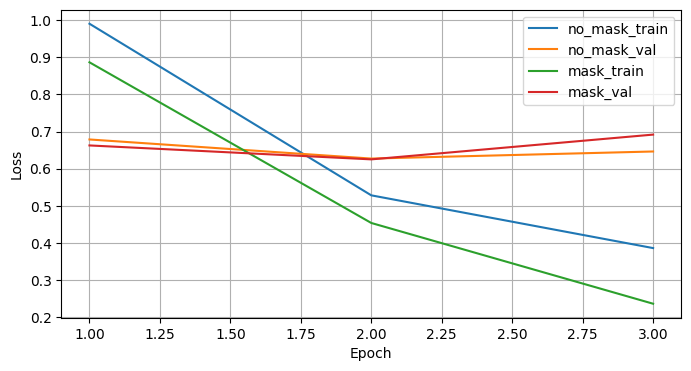

In [7]:
# 同时训练两个模型（不带 mask / 带 mask），并都生成 responses，分别保存结果。
from types import SimpleNamespace
# 基本参数模板，按需修改路径和超参
base = dict(
    data='instruction-data.json',
    model_config='355M',
    model_path='gpt2-355M.pth',
    num_epochs=3,
    batch_size=8,
    grad_accum_steps=1,
    lr=2e-5,
    weight_decay=0.05,
    use_amp=True,
    max_grad_norm=1.0,
    log_interval=10,
    early_stop_patience=1,
    min_delta=1e-4,
    allowed_max_length=512,
    max_new_tokens=128,
    generate_responses=1
)
# 不带 mask 的配置
args_no_mask = SimpleNamespace(**{**base, **{'mask_instructions':0, 'save_path':'sft_no_mask.pth'}})
# 带 mask 的配置
args_mask = SimpleNamespace(**{**base, **{'mask_instructions':1, 'save_path':'sft_mask.pth'}})
# 运行不带 mask 的实验
print('=== Running without instruction masking ===')
res_no_mask = main(args_no_mask)
print('No-mask summary:')
print('  model saved to', res_no_mask['model_path'])
print('  responses saved to', res_no_mask['responses_file'])
# 运行带 mask 的实验
print('=== Running WITH instruction masking ===')
res_mask = main(args_mask)
print('Mask summary:')
print('  model saved to', res_mask['model_path'])
print('  responses saved to', res_mask['responses_file'])
# 简要绘制两者的损失曲线对比（如果可用）
try:
    import matplotlib.pyplot as plt
    x1 = list(range(1, len(res_no_mask['train_losses'])+1))
    x2 = list(range(1, len(res_mask['train_losses'])+1))
    plt.figure(figsize=(8,4))
    if res_no_mask['train_losses']:
        plt.plot(x1, res_no_mask['train_losses'], label='no_mask_train')
    if res_no_mask['val_losses']:
        plt.plot(x1, res_no_mask['val_losses'], label='no_mask_val')
    if res_mask['train_losses']:
        plt.plot(x2, res_mask['train_losses'], label='mask_train')
    if res_mask['val_losses']:
        plt.plot(x2, res_mask['val_losses'], label='mask_val')
    plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.show()
except Exception as e:
    print('Could not plot comparison:', e)

In [8]:
# 如果需要单独运行第二次实验，可在此处调用 main(args_mask) 或 main(args_no_mask)
print('Use the previous cell to run both experiments.')

Use the previous cell to run both experiments.
